In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# neurokit2  → PPG peak detection + HRV computation | reportlab  → PDF report generation
!pip install neurokit2 reportlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 4.3 MB/s eta 0:00:00


In [3]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)

print('All imports OK')

All imports OK


In [4]:
base      = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS'
ar_path   = f'{base}/Datasets/AffectiveROAD'

# Input sub-folders
bio_dir   = f'{ar_path}/Bioharness'
e4_dir    = f'{ar_path}/E4'

# Output folders
out_base      = f'{base}/Outputs/AffectiveROAD'
out_per_drive = f'{out_base}/per_drive'
out_combined  = f'{out_base}/combined'
out_plots     = f'{out_base}/plots'
out_reports   = f'{out_base}/reports'

for folder in [out_per_drive, out_combined, out_plots, out_reports]:
    os.makedirs(folder, exist_ok=True)

print('Folder structure ready:')
print(f'  {out_base}/')
print(f'    per_drive/  ← per-drive feature arrays')
print(f'    combined/   ← all drives merged')
print(f'    plots/      ← visualisations')
print(f'    reports/    ← PDF report')

Folder structure ready:
  /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/AffectiveROAD/
    per_drive/  ← per-drive feature arrays
    combined/   ← all drives merged
    plots/      ← visualisations
    reports/    ← PDF report


In [5]:
ann_e4  = pd.read_csv(f'{e4_dir}/Annot_E4_Left.csv')
ann_bio = pd.read_csv(f'{bio_dir}/Annot_Bioharness.csv')

print('E4 annotation shape:', ann_e4.shape)
print('Bioharness annotation shape:', ann_bio.shape)
print()
print('Drive IDs in E4 annotations:')
print(ann_e4['Drive-id'].tolist())
print()
print('Drive IDs in Bioharness annotations:')
print(ann_bio['Drive_id'].tolist())

E4 annotation shape: (13, 21)
Bioharness annotation shape: (13, 21)

Drive IDs in E4 annotations:
['Drv1', 'Drv2', 'Drv3', 'Drv4', 'Drv5', 'Drv6', 'Drv7', 'Drv8', 'Drv9', 'Drv10', 'Drv11', 'Drv12', 'Drv13']

Drive IDs in Bioharness annotations:
['Drv1', 'Drv2', 'Drv3', 'Drv4', 'Drv5', 'Drv6', 'Drv7', 'Drv8', 'Drv9', 'Drv10', 'Drv11', 'Drv12', 'Drv13']


In [6]:
DRV_ID = 'Drv1'
DRV_N  = 1     # folder number

# ── 6a. Load Drv1 E4 signals ──────────────────────────────
e4_folder = f'{e4_dir}/{DRV_N}-E4-{DRV_ID}/Left'

def _load_e4_single(path):
    """Read an E4 file. Returns (unix_start, sample_rate, data_array)."""
    with open(path) as f:
        lines = f.read().strip().split('\n')
    start = float(lines[0].split(',')[0])
    fs    = float(lines[1].split(',')[0])
    data  = np.array([list(map(float, l.split(','))) for l in lines[2:]])
    if data.ndim == 2 and data.shape[1] == 1:
        data = data.flatten()
    return start, fs, data

_, bvp_fs,  bvp_raw  = _load_e4_single(f'{e4_folder}/BVP.csv')
_, temp_fs, temp_raw = _load_e4_single(f'{e4_folder}/TEMP.csv')
_, acc_fs,  acc_raw  = _load_e4_single(f'{e4_folder}/ACC.csv')

bio_df = pd.read_csv(f'{bio_dir}/Bio_{DRV_ID}.csv', sep=';')

print(f'=== Drv1 signal overview ===')
print(f'BVP  : {len(bvp_raw)} samples @ {bvp_fs:.0f} Hz  = {len(bvp_raw)/bvp_fs/60:.1f} min')
print(f'TEMP : {len(temp_raw)} samples @ {temp_fs:.0f} Hz  = {len(temp_raw)/temp_fs/60:.1f} min')
print(f'ACC  : {acc_raw.shape} @ {acc_fs:.0f} Hz  = {len(acc_raw)/acc_fs/60:.1f} min')
print(f'Bio  : {bio_df.shape}  @ 1 Hz  = {len(bio_df)/60:.1f} min')

print(f'\nBVP  range  : {bvp_raw.min():.2f} to {bvp_raw.max():.2f}')
print(f'BVP  zeros  : {(bvp_raw==0).sum()} ({(bvp_raw==0).mean()*100:.1f}%)')
print(f'TEMP range  : {temp_raw.min():.2f} to {temp_raw.max():.2f}')
print(f'TEMP startup artifacts (first 4 samples): {temp_raw[:4]}')
print(f'TEMP valid (25-45°C): {((temp_raw>25)&(temp_raw<45)).sum()} / {len(temp_raw)}')

print(f'\nBioharness columns : {list(bio_df.columns)}')
print(f'HR=0 rows          : {(bio_df["HR"]==0).sum()}')
print(f'BR valid (6-40)    : {((bio_df["BR"]>=6)&(bio_df["BR"]<=40)).sum()} / {len(bio_df)}')
print(f'BR range           : {bio_df["BR"].min():.1f} to {bio_df["BR"].max():.1f}')

# ── 6b. Verify annotation durations ──────────────────────
drv1_e4  = ann_e4[ann_e4['Drive-id']  == DRV_ID].iloc[0]
drv1_bio = ann_bio[ann_bio['Drive_id'] == DRV_ID].iloc[0]

print(f'\n=== Annotation verification (durations must match) ===')
for seg, s_col, e_col in [('Rest',  'Rest_Start',  'Rest_End'),
                           ('City1', 'City1_Start', 'City1_End'),
                           ('Hwy',   'Hwy_Start',   'Hwy_End'),
                           ('City2', 'City2_Start', 'City2_End')]:
    e4_dur  = (drv1_e4[e_col]  - drv1_e4[s_col])  / 4   # 4Hz → seconds
    bio_dur = (drv1_bio[e_col] - drv1_bio[s_col])  / 1   # 1Hz → seconds
    match   = 'OK' if abs(e4_dur - bio_dur) <= 1 else 'MISMATCH'
    print(f'  {seg:6s}: E4={e4_dur:.0f}s  Bio={bio_dur:.0f}s  [{match}]')

=== Drv1 signal overview ===
BVP  : 365530 samples @ 64 Hz  = 95.2 min
TEMP : 22840 samples @ 4 Hz  = 95.2 min
ACC  : (182766, 3) @ 32 Hz  = 95.2 min
Bio  : (7160, 5)  @ 1 Hz  = 119.3 min

BVP  range  : -1009.08 to 620.40
BVP  zeros  : 214 (0.1%)
TEMP range  : 34.11 to 382.18
TEMP startup artifacts (first 4 samples): [382.18 382.18 382.18 382.18]
TEMP valid (25-45°C): 22836 / 22840

Bioharness columns : ['Time', 'HR', 'BR', 'Posture', 'Activity']
HR=0 rows          : 11
BR valid (6-40)    : 6928 / 7160
BR range           : 5.4 to 60.2

=== Annotation verification (durations must match) ===
  Rest  : E4=900s  Bio=900s  [OK]
  City1 : E4=278s  Bio=278s  [OK]
  Hwy   : E4=280s  Bio=280s  [OK]
  City2 : E4=643s  Bio=643s  [OK]


In [7]:
def load_e4_signals(drive_n, drive_id):
    """
    Load BVP, TEMP, ACC from the Left E4 wristband for one drive.
    Returns a dict with arrays and their sample rates.
    """
    folder = f'{e4_dir}/{drive_n}-E4-{drive_id}/Left'
    _, bvp_fs,  bvp  = _load_e4_single(f'{folder}/BVP.csv')
    _, temp_fs, temp = _load_e4_single(f'{folder}/TEMP.csv')
    _, acc_fs,  acc  = _load_e4_single(f'{folder}/ACC.csv')

    # Remove startup TEMP artifacts (first 4 samples are ~382°C)
    # These appear before any annotated segment, so they rarely affect windows,
    # but we zero them out as a safety measure.
    temp[:4] = np.nan

    return {
        'bvp':  bvp,   'bvp_fs':  bvp_fs,
        'temp': temp,  'temp_fs': temp_fs,
        'acc':  acc,   'acc_fs':  acc_fs,
    }


def load_e4_signals_drv2():
    """
    Special loader for Drv2 which has two E4 recordings:
      Left1 (unix start 1494232516) → covers outbound Rest segment
      Left2 (unix start 1494236127) → covers all City and return Rest segments

    Left2 starts at session second 3611 = 4Hz index 14444.
    We return both signal dicts and the 4Hz offset for Left2.
    """
    folder1 = f'{e4_dir}/2-E4-Drv2/Left1'
    folder2 = f'{e4_dir}/2-E4-Drv2/Left2'

    _, _, bvp1  = _load_e4_single(f'{folder1}/BVP.csv')
    _, _, temp1 = _load_e4_single(f'{folder1}/TEMP.csv')
    _, _, acc1  = _load_e4_single(f'{folder1}/ACC.csv')
    temp1[:4]   = np.nan

    _, _, bvp2  = _load_e4_single(f'{folder2}/BVP.csv')
    _, _, temp2 = _load_e4_single(f'{folder2}/TEMP.csv')
    _, _, acc2  = _load_e4_single(f'{folder2}/ACC.csv')
    temp2[:4]   = np.nan

    left1 = {'bvp': bvp1, 'temp': temp1, 'acc': acc1}
    left2 = {'bvp': bvp2, 'temp': temp2, 'acc': acc2}

    # Left2 starts at 4Hz index 14444 in the session timeline.
    # To get the index within Left2 itself: subtract this offset.
    left2_4hz_offset = 14444   # = 3611 seconds × 4Hz
    left2_1hz_offset = 3611    # for Bioharness (1Hz)

    return left1, left2, left2_4hz_offset, left2_1hz_offset


def load_bioharness(drive_id):
    """
    Load the Bioharness CSV for one drive.
    The file is semicolon-separated.
    Columns: Time, HR, BR, Posture, Activity
    """
    path = f'{bio_dir}/Bio_{drive_id}.csv'
    df   = pd.read_csv(path, sep=';')
    return df


print('Signal loading functions defined.')

Signal loading functions defined.


In [8]:
MIN_CLEAN_BEATS = 8

def extract_hrv(bvp_window, fs=64):
    """
    Extract 5 HRV features from a 60-second BVP window.

    Returns:
        (mean_HR, mean_RR, SDNN, RMSSD, pNN50)
        or None if the window has too few clean beats.

    Units:
        mean_HR  → bpm
        mean_RR  → milliseconds
        SDNN     → milliseconds
        RMSSD    → milliseconds
        pNN50    → percent (0–100)
    """
    # Clean the PPG signal
    bvp_clean = nk.ppg_clean(bvp_window, sampling_rate=fs)

    # Find systolic peaks
    info      = nk.ppg_findpeaks(bvp_clean, sampling_rate=fs)
    peak_idx  = info['PPG_Peaks']

    if len(peak_idx) < MIN_CLEAN_BEATS + 1:
        return None

    # RR intervals in milliseconds
    rr_ms = np.diff(peak_idx) / fs * 1000

    # Stage 1: physiological range
    rr_ms = rr_ms[(rr_ms >= 273) & (rr_ms <= 2000)]
    if len(rr_ms) < MIN_CLEAN_BEATS:
        return None

    # Stage 2: local consistency filter (motion artifact removal)
    local_med = np.median(rr_ms)
    rr_clean  = rr_ms[np.abs(rr_ms - local_med) / local_med <= 0.20]
    if len(rr_clean) < MIN_CLEAN_BEATS:
        return None

    mean_rr = np.mean(rr_clean)
    mean_hr = 60000 / mean_rr
    sdnn    = np.std(rr_clean, ddof=1)
    rmssd   = np.sqrt(np.mean(np.diff(rr_clean) ** 2))
    pnn50   = np.sum(np.abs(np.diff(rr_clean)) > 50) / len(rr_clean) * 100

    return mean_hr, mean_rr, sdnn, rmssd, pnn50


print('HRV extraction function defined.')
print(f'Minimum clean beats required per window: {MIN_CLEAN_BEATS}')

HRV extraction function defined.
Minimum clean beats required per window: 8


In [9]:
# Feature extraction for one window ─────────────
FEATURE_NAMES = [
    'mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50',
    'mean_BR', 'std_BR',
    'mean_temp', 'std_temp',
    'mean_acc_mag', 'std_acc_mag'
]
N_FEATURES = len(FEATURE_NAMES)

BR_MIN,   BR_MAX   = 6,  40
TEMP_MIN, TEMP_MAX = 25, 45
BR_MIN_VALID_FRAC  = 0.50

def extract_window_features(bvp_win, temp_win, acc_win, br_win):
    features = np.full(N_FEATURES, np.nan)

    # HRV (features 0–4)
    hrv = extract_hrv(bvp_win, fs=64)
    if hrv is None:
        return None
    features[0:5] = hrv

    # BR (features 5–6)
    valid_br = br_win[(br_win >= BR_MIN) & (br_win <= BR_MAX)]
    if len(valid_br) / len(br_win) < BR_MIN_VALID_FRAC:
        return None  # window unusable — too many BR motion artifacts
    features[5] = np.mean(valid_br)
    features[6] = np.std(valid_br)

    # Temp (features 7–8)
    valid_t = temp_win[(temp_win >= TEMP_MIN) & (temp_win <= TEMP_MAX)]
    if len(valid_t) == 0:
        return None  # window unusable — all TEMP samples out of range
    features[7] = np.mean(valid_t)
    features[8] = np.std(valid_t)

    # ACC magnitude (features 9–10)
    # E4 ACC unit is 1/64g — convert to g first
    acc_g   = acc_win / 64.0
    acc_mag = np.sqrt(np.sum(acc_g ** 2, axis=1))
    features[9]  = np.mean(acc_mag)
    features[10] = np.std(acc_mag)

    return features

print('Feature extraction function defined.')
print(f'Total features per window: {N_FEATURES}')
print('Feature list:', FEATURE_NAMES)

Feature extraction function defined.
Total features per window: 11
Feature list: ['mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'mean_BR', 'std_BR', 'mean_temp', 'std_temp', 'mean_acc_mag', 'std_acc_mag']


In [10]:
# ── Cell 10: Window segmentation ─────────────────────────
#
# Parameters
#   Window duration : 60 seconds
#   Overlap         : 50%  (step = 30 seconds)
#
# Annotation index reference rates:
#   E4 annotation  → 4 Hz  (divide by 4 to get seconds)
#   Bioharness     → 1 Hz  (already in seconds)
#
# For each signal we compute sample indices from the window start in seconds:
#   BVP  (64 Hz) : sample = sec * 64
#   ACC  (32 Hz) : sample = sec * 32
#   TEMP ( 4 Hz) : sample = sec *  4   ← same as E4 annotation index directly
#   BR   ( 1 Hz) : sample = sec *  1   ← Bioharness annotation index directly

WIN_SEC   = 60
STEP_SEC  = 30    # 50% overlap

# Samples per window at each rate
WIN_BVP   = WIN_SEC * 64   # 3840
WIN_ACC   = WIN_SEC * 32   # 1920
WIN_TEMP  = WIN_SEC *  4   #  240
WIN_BR    = WIN_SEC *  1   #   60


def segment_drive(
    e4_signals,
    bio_df,
    seg_start_4hz,   # annotation index in 4Hz units (E4)
    seg_end_4hz,     # annotation index in 4Hz units (E4)
    seg_start_1hz,   # annotation index in 1Hz units (Bioharness)
    label,           # 0=baseline, 1=stress
    quality_log,     # list to append quality notes
    drive_id,
):
    """
    Extract all 60-second windows from one annotated segment of one drive.

    Returns: list of feature vectors (np.array shape 11) with matching labels.
    """
    bvp  = e4_signals['bvp']
    temp = e4_signals['temp']
    acc  = e4_signals['acc']
    br   = bio_df['BR'].values

    seg_dur_sec = (seg_end_4hz - seg_start_4hz) / 4
    if seg_dur_sec < WIN_SEC:
        quality_log.append(f'{drive_id}: segment too short ({seg_dur_sec:.0f}s), skipped')
        return [], []

    features_list = []
    labels_list   = []
    skipped_hrv   = 0

    n_windows = int((seg_dur_sec - WIN_SEC) // STEP_SEC) + 1

    for i in range(n_windows):
        win_start_sec = (seg_start_4hz / 4) + i * STEP_SEC

        # Slice each signal at its own sample rate
        b_s = int(win_start_sec * 64)
        a_s = int(win_start_sec * 32)
        t_s = int(win_start_sec *  4)
        r_s = int(seg_start_1hz) + i * STEP_SEC

        bvp_win  = bvp [b_s : b_s + WIN_BVP]
        acc_win  = acc [a_s : a_s + WIN_ACC]
        temp_win = temp[t_s : t_s + WIN_TEMP]
        br_win   = br  [r_s : r_s + WIN_BR]

        # Safety: skip if any signal is too short at boundaries
        if (len(bvp_win) < WIN_BVP or len(acc_win) < WIN_ACC
                or len(temp_win) < WIN_TEMP or len(br_win) < WIN_BR):
            continue

        # Replace NaN in temp window with interpolation
        if np.any(np.isnan(temp_win)):
            temp_win = pd.Series(temp_win).interpolate().values

        feats = extract_window_features(bvp_win, temp_win, acc_win, br_win)

        if feats is None:
            skipped_hrv += 1
            continue

        features_list.append(feats)
        labels_list.append(label)

    if skipped_hrv > 0:
        quality_log.append(
            f'{drive_id}: {skipped_hrv}/{n_windows} windows skipped '
            f'(HRV extraction failed) in {"baseline" if label==0 else "stress"}'
        )

    return features_list, labels_list


print('Window segmentation function defined.')
print(f'Window: {WIN_SEC}s  |  Step: {STEP_SEC}s (50% overlap)')

Window segmentation function defined.
Window: 60s  |  Step: 30s (50% overlap)


In [11]:
# Process all 13 drives

drive_map = {f'Drv{n}': n for n in range(1, 14)}

BASELINE_SEGS = [
    ('Rest_Start',   'Rest_End'),
    ('Rest_Start.1', 'Rest_End.1'),
]
STRESS_SEGS = [
    ('City1_Start',   'City1_End'),
    ('City2_Start',   'City2_End'),
    ('City2_Start.1', 'City2_End.1'),
    ('City1_Start.1', 'City1_End.1'),
]

all_features  = []
all_labels    = []
all_drive_ids = []
summary       = {}
quality_log   = []


for drive_id, drive_n in drive_map.items():
    print(f'\n--- Processing {drive_id} ---')

    # ── Load signals ──────────────────────────────────────
    try:
        if drive_id == 'Drv2':
            e4_left1, e4_left2, e4_off_4hz, e4_off_1hz = load_e4_signals_drv2()
        else:
            e4 = load_e4_signals(drive_n, drive_id)
        bio = load_bioharness(drive_id)
    except FileNotFoundError as err:
        quality_log.append(f'{drive_id}: FILE NOT FOUND – {err}')
        print(f'  SKIPPED (file not found)')
        continue

    # ── Get annotations ───────────────────────────────────
    row_e4  = ann_e4[ann_e4['Drive-id']  == drive_id].iloc[0]
    row_bio = ann_bio[ann_bio['Drive_id'] == drive_id].iloc[0]

    drive_feats  = []
    drive_labels = []

    if drive_id == 'Drv2':
        # Outbound Rest → Left1 (annotation indices used directly)
        for s_col, e_col in [('Rest_Start', 'Rest_End')]:
            f_list, l_list = segment_drive(
                e4_signals    = e4_left1,
                bio_df        = bio,
                seg_start_4hz = int(row_e4[s_col]),
                seg_end_4hz   = int(row_e4[e_col]),
                seg_start_1hz = int(row_bio[s_col]),
                label         = 0,
                quality_log   = quality_log,
                drive_id      = drive_id,
            )
            drive_feats  += f_list
            drive_labels += l_list

        # City segments → Left2 (subtract offset from annotation indices)
        for s_col, e_col in [
            ('City1_Start',   'City1_End'),
            ('City2_Start',   'City2_End'),
            ('City2_Start.1', 'City2_End.1'),
            ('City1_Start.1', 'City1_End.1'),
        ]:
            f_list, l_list = segment_drive(
                e4_signals    = e4_left2,
                bio_df        = bio,
                seg_start_4hz = int(row_e4[s_col]) - e4_off_4hz,
                seg_end_4hz   = int(row_e4[e_col]) - e4_off_4hz,
                seg_start_1hz = int(row_bio[s_col]) - e4_off_1hz,
                label         = 1,
                quality_log   = quality_log,
                drive_id      = drive_id,
            )
            drive_feats  += f_list
            drive_labels += l_list

        # Return Rest → Left2 (subtract offset)
        for s_col, e_col in [('Rest_Start.1', 'Rest_End.1')]:
            f_list, l_list = segment_drive(
                e4_signals    = e4_left2,
                bio_df        = bio,
                seg_start_4hz = int(row_e4[s_col]) - e4_off_4hz,
                seg_end_4hz   = int(row_e4[e_col]) - e4_off_4hz,
                seg_start_1hz = int(row_bio[s_col]) - e4_off_1hz,
                label         = 0,
                quality_log   = quality_log,
                drive_id      = drive_id,
            )
            drive_feats  += f_list
            drive_labels += l_list

    else:
        # All other drives — normal processing
        for s_col, e_col in BASELINE_SEGS:
            f_list, l_list = segment_drive(
                e4_signals    = e4,
                bio_df        = bio,
                seg_start_4hz = int(row_e4[s_col]),
                seg_end_4hz   = int(row_e4[e_col]),
                seg_start_1hz = int(row_bio[s_col]),
                label         = 0,
                quality_log   = quality_log,
                drive_id      = drive_id,
            )
            drive_feats  += f_list
            drive_labels += l_list

        for s_col, e_col in STRESS_SEGS:
            f_list, l_list = segment_drive(
                e4_signals    = e4,
                bio_df        = bio,
                seg_start_4hz = int(row_e4[s_col]),
                seg_end_4hz   = int(row_e4[e_col]),
                seg_start_1hz = int(row_bio[s_col]),
                label         = 1,
                quality_log   = quality_log,
                drive_id      = drive_id,
            )
            drive_feats  += f_list
            drive_labels += l_list

    # ── Count windows ─────────────────────────────────────
    n_baseline = sum(1 for l in drive_labels if l == 0)
    n_stress   = sum(1 for l in drive_labels if l == 1)

    if len(drive_feats) == 0:
        quality_log.append(f'{drive_id}: zero windows extracted, drive skipped')
        print(f'  WARNING: no windows extracted')
        continue

    X_drive = np.array(drive_feats)
    y_drive = np.array(drive_labels)

    # ── Quality checks ────────────────────────────────────
    n_all_nan  = np.sum(np.all(np.isnan(X_drive), axis=1))
    n_dup      = len(X_drive) - len(np.unique(X_drive, axis=0))
    nan_counts = np.sum(np.isnan(X_drive), axis=0)

    if n_all_nan > 0:
        quality_log.append(f'{drive_id}: {n_all_nan} fully-NaN rows')
    if n_dup > 0:
        quality_log.append(f'{drive_id}: {n_dup} duplicate windows (expected with 50% overlap)')
    if np.any(nan_counts > 0):
        nan_info = {FEATURE_NAMES[i]: int(nan_counts[i])
                    for i in range(N_FEATURES) if nan_counts[i] > 0}
        quality_log.append(f'{drive_id}: NaN counts per feature: {nan_info}')

    # ── Per-drive Z-score normalisation ───────────────────
    baseline_mask = (y_drive == 0)
    X_baseline    = X_drive[baseline_mask]

    feat_mean = np.nanmean(X_baseline, axis=0)
    feat_std  = np.nanstd(X_baseline,  axis=0)
    feat_std  = np.where(feat_std == 0, 1e-8, feat_std)

    X_norm = (X_drive - feat_mean) / feat_std

    # ── Save per-drive files ──────────────────────────────
    np.save(f'{out_per_drive}/AR_{drive_id}_features_raw.npy',  X_drive)
    np.save(f'{out_per_drive}/AR_{drive_id}_features_norm.npy', X_norm)
    np.save(f'{out_per_drive}/AR_{drive_id}_labels.npy',        y_drive)
    np.save(f'{out_per_drive}/AR_{drive_id}_norm_mean.npy',     feat_mean)
    np.save(f'{out_per_drive}/AR_{drive_id}_norm_std.npy',      feat_std)

    # ── Accumulate ────────────────────────────────────────
    all_features.append(X_drive)
    all_labels.append(y_drive)
    all_drive_ids.extend([drive_id] * len(y_drive))

    summary[drive_id] = {
        'n_baseline': n_baseline,
        'n_stress':   n_stress,
        'n_total':    len(y_drive),
        'nan_br':     int(nan_counts[5]) if nan_counts[5] > 0 else 0,
    }
    print(f'  Baseline: {n_baseline} windows  |  Stress: {n_stress} windows')


print('\n=== All drives processed ===')


--- Processing Drv1 ---
  Baseline: 58 windows  |  Stress: 50 windows

--- Processing Drv2 ---
  Baseline: 15 windows  |  Stress: 45 windows

--- Processing Drv3 ---
  Baseline: 58 windows  |  Stress: 46 windows

--- Processing Drv4 ---
  Baseline: 57 windows  |  Stress: 53 windows

--- Processing Drv5 ---
  Baseline: 59 windows  |  Stress: 57 windows

--- Processing Drv6 ---
  Baseline: 58 windows  |  Stress: 50 windows

--- Processing Drv7 ---
  Baseline: 57 windows  |  Stress: 48 windows

--- Processing Drv8 ---
  Baseline: 58 windows  |  Stress: 54 windows

--- Processing Drv9 ---
  Baseline: 58 windows  |  Stress: 40 windows

--- Processing Drv10 ---
  Baseline: 62 windows  |  Stress: 50 windows

--- Processing Drv11 ---
  Baseline: 60 windows  |  Stress: 54 windows

--- Processing Drv12 ---
  Baseline: 58 windows  |  Stress: 53 windows

--- Processing Drv13 ---
  Baseline: 58 windows  |  Stress: 55 windows

=== All drives processed ===


In [12]:
# Combine all drives into single arrays

X_all         = np.vstack(all_features)          # shape: (total_windows, 11)
y_all         = np.concatenate(all_labels)        # shape: (total_windows,)
drive_ids_all = np.array(all_drive_ids)           # shape: (total_windows,)

print('=== Combined dataset ===')
print(f'Total windows    : {len(X_all)}')
print(f'Baseline windows : {(y_all==0).sum()}')
print(f'Stress windows   : {(y_all==1).sum()}')
print(f'Features         : {X_all.shape[1]}')
print(f'Drives included  : {len(np.unique(drive_ids_all))}')
print()

# Check for all-NaN rows (should be 0 because HRV guard)
n_allnan = np.sum(np.all(np.isnan(X_all), axis=1))
print(f'All-NaN rows     : {n_allnan}  (should be 0)')

# NaN summary per feature
print('\nNaN count per feature across all windows:')
for i, name in enumerate(FEATURE_NAMES):
    n = int(np.sum(np.isnan(X_all[:, i])))
    pct = n / len(X_all) * 100
    flag = '  ← check quality log' if pct > 20 else ''
    print(f'  {name:15s}: {n:4d}  ({pct:.1f}%){flag}')

# Save
np.save(f'{out_combined}/AR_X_all_raw.npy',   X_all)
np.save(f'{out_combined}/AR_y_all.npy',       y_all)
np.save(f'{out_combined}/AR_drive_ids.npy',   drive_ids_all)
print('\nCombined arrays saved.')

=== Combined dataset ===
Total windows    : 1371
Baseline windows : 716
Stress windows   : 655
Features         : 11
Drives included  : 13

All-NaN rows     : 0  (should be 0)

NaN count per feature across all windows:
  mean_HR        :    0  (0.0%)
  mean_RR        :    0  (0.0%)
  SDNN           :    0  (0.0%)
  RMSSD          :    0  (0.0%)
  pNN50          :    0  (0.0%)
  mean_BR        :    0  (0.0%)
  std_BR         :    0  (0.0%)
  mean_temp      :    0  (0.0%)
  std_temp       :    0  (0.0%)
  mean_acc_mag   :    0  (0.0%)
  std_acc_mag    :    0  (0.0%)

Combined arrays saved.


In [13]:
# Save feature names + quality log

# Feature names JSON
feat_json = {
    'dataset':       'AffectiveROAD',
    'n_features':    N_FEATURES,
    'feature_names': FEATURE_NAMES,
    'feature_sources': {
        'mean_HR':      'BVP (E4 Left, 64Hz) → PPG peak detection → RR intervals',
        'mean_RR':      'BVP (E4 Left, 64Hz) → PPG peak detection → RR intervals',
        'SDNN':         'BVP (E4 Left, 64Hz) → PPG peak detection → RR intervals',
        'RMSSD':        'BVP (E4 Left, 64Hz) → PPG peak detection → RR intervals',
        'pNN50':        'BVP (E4 Left, 64Hz) → PPG peak detection → RR intervals',
        'mean_BR':      'Zephyr Bioharness (1Hz), valid range 6–40 breaths/min',
        'std_BR':       'Zephyr Bioharness (1Hz), valid range 6–40 breaths/min',
        'mean_temp':    'TEMP.csv (E4 Left, 4Hz), valid range 25–45°C',
        'std_temp':     'TEMP.csv (E4 Left, 4Hz), valid range 25–45°C',
        'mean_acc_mag': 'ACC.csv (E4 Left, 32Hz), magnitude = sqrt(x²+y²+z²), unit: g',
        'std_acc_mag':  'ACC.csv (E4 Left, 32Hz), magnitude = sqrt(x²+y²+z²), unit: g',
    },
    'labelling': {
        '0': 'Baseline (Rest segments: outbound + return)',
        '1': 'Stress (City1 + City2 segments: outbound + return)',
        'skipped': 'Highway (Hwy) and calibration (Z) segments'
    },
    'windowing': {
        'duration_sec': WIN_SEC,
        'step_sec':     STEP_SEC,
        'overlap_pct':  50
    },
    'hrv_notes': (
        'HRV computed from wrist PPG (BVP, 64Hz), not raw ECG. '
        'Two-stage artifact filter applied: (1) physiological range 273–2000ms; '
        '(2) local-median consistency ±20%. '
        'Windows with fewer than 8 clean RR intervals are excluded. '
        'Frequency-domain HRV (LF/HF) not computed: 60-second windows '
        'are too short for reliable spectral estimation.'
    ),
    'br_notes': (
        'BR from Bioharness chest pressure sensor. Values outside 6–40 breaths/min '
        'treated as motion artifacts and excluded. Windows where fewer than 50% of '
        'samples pass the validity filter are rejected entirely — no NaN propagates '
        'to the feature array.'
    ),
    'temp_notes': (
        'First 4 TEMP samples per session set to NaN (sensor warmup artifact at 382°C). '
        'These occur before all annotated segments so no window is affected.'
    ),
}

with open(f'{base}/Outputs/AffectiveROAD_feature_names.json', 'w') as fp:
    json.dump(feat_json, fp, indent=2)
print('Feature names JSON saved.')

# Quality log
if quality_log:
    print('\n=== Quality log ===')
    for note in quality_log:
        print(f'  {note}')
else:
    print('Quality log: no issues.')

Feature names JSON saved.

=== Quality log ===
  Drv7: 1/29 windows skipped (HRV extraction failed) in baseline


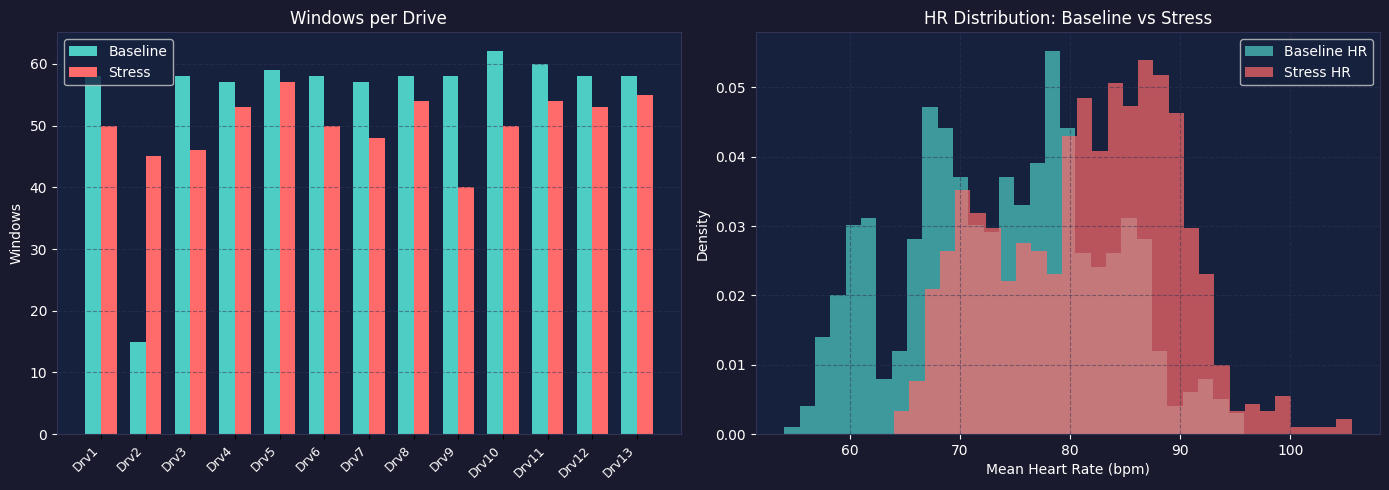

Plot saved.


In [14]:
# Per-drive window count plot ──────────────────

drives  = list(summary.keys())
n_base  = [summary[d]['n_baseline'] for d in drives]
n_str   = [summary[d]['n_stress']   for d in drives]
x       = np.arange(len(drives))
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          facecolor='#1a1a2e')

# ── Left: window counts ───────────────────────────────────
ax = axes[0]
ax.set_facecolor('#16213e')
b1 = ax.bar(x - width/2, n_base, width, label='Baseline',
            color='#4ecdc4', edgecolor='none')
b2 = ax.bar(x + width/2, n_str,  width, label='Stress',
            color='#ff6b6b', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(drives, rotation=45, ha='right',
                   color='white', fontsize=9)
ax.tick_params(axis='y', colors='white')
ax.set_ylabel('Windows', color='white')
ax.set_title('Windows per Drive', color='white', fontsize=12)
ax.legend(facecolor='#16213e', labelcolor='white')
ax.spines[:].set_color('#333355')
ax.grid(axis='y', color='#333355', linestyle='--', alpha=0.5)

# ── Right: feature distributions (baseline vs stress) ────
ax2 = axes[1]
ax2.set_facecolor('#16213e')

base_hr   = X_all[y_all==0, 0]  # mean_HR baseline
stress_hr = X_all[y_all==1, 0]  # mean_HR stress
ax2.hist(base_hr[~np.isnan(base_hr)],   bins=30, alpha=0.7,
         color='#4ecdc4', label='Baseline HR', density=True)
ax2.hist(stress_hr[~np.isnan(stress_hr)], bins=30, alpha=0.7,
         color='#ff6b6b', label='Stress HR',   density=True)
ax2.tick_params(colors='white')
ax2.set_xlabel('Mean Heart Rate (bpm)', color='white')
ax2.set_ylabel('Density', color='white')
ax2.set_title('HR Distribution: Baseline vs Stress', color='white', fontsize=12)
ax2.legend(facecolor='#16213e', labelcolor='white')
ax2.spines[:].set_color('#333355')
ax2.grid(color='#333355', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{out_plots}/AR_window_summary.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Plot saved.')

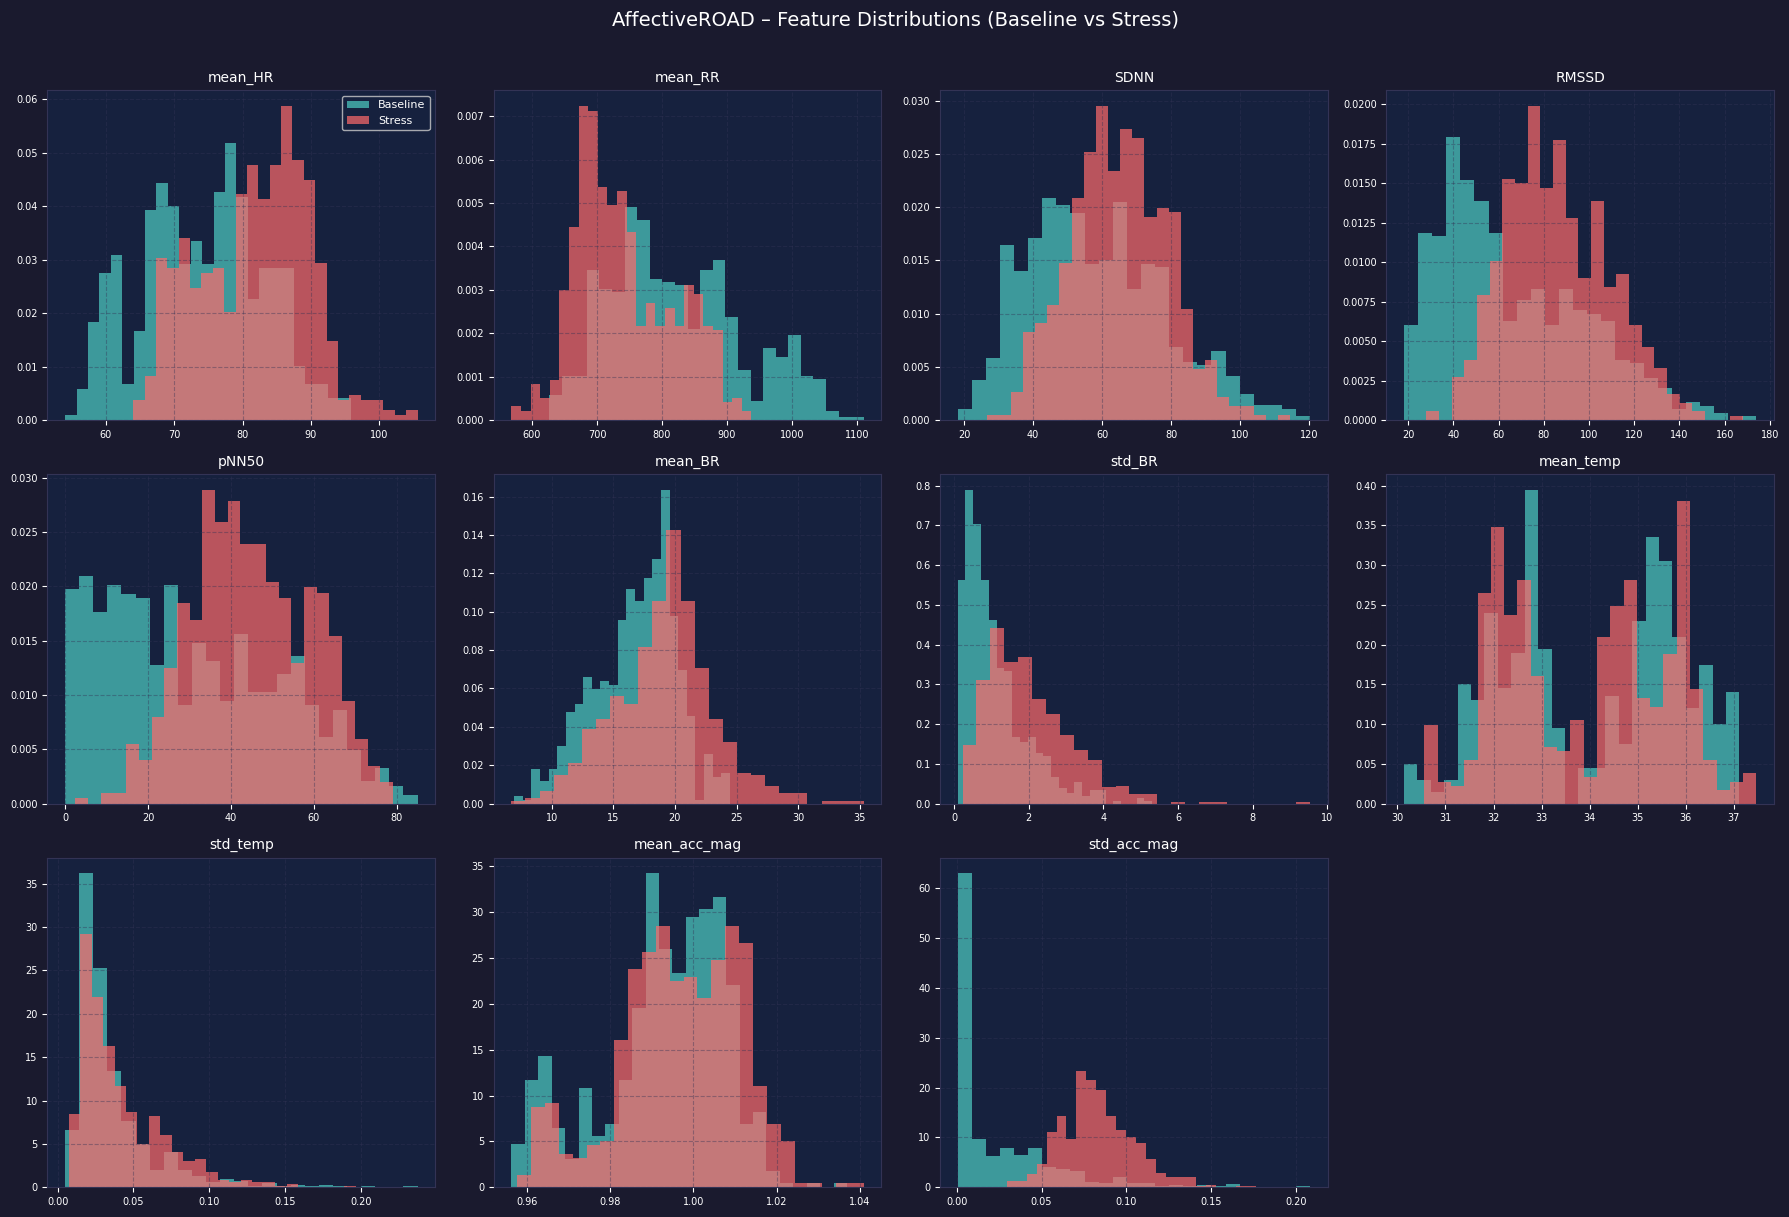

Distribution plot saved.


In [15]:
# Feature distribution plots
# One histogram per feature: baseline (teal) vs stress (red)

fig, axes = plt.subplots(3, 4, figsize=(18, 12),
                          facecolor='#1a1a2e')
fig.suptitle('AffectiveROAD – Feature Distributions (Baseline vs Stress)',
             color='white', fontsize=14, y=1.01)

axes_flat = axes.flatten()

for i, name in enumerate(FEATURE_NAMES):
    ax = axes_flat[i]
    ax.set_facecolor('#16213e')

    base_vals   = X_all[y_all==0, i]
    stress_vals = X_all[y_all==1, i]
    base_vals   = base_vals[~np.isnan(base_vals)]
    stress_vals = stress_vals[~np.isnan(stress_vals)]

    ax.hist(base_vals,   bins=25, alpha=0.7, color='#4ecdc4',
            label='Baseline', density=True)
    ax.hist(stress_vals, bins=25, alpha=0.7, color='#ff6b6b',
            label='Stress',   density=True)
    ax.set_title(name, color='white', fontsize=10)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[:].set_color('#333355')
    ax.grid(color='#333355', linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(facecolor='#16213e', labelcolor='white', fontsize=8)

# Hide the 12th subplot (we have 11 features)
axes_flat[11].set_visible(False)

plt.tight_layout()
plt.savefig(f'{out_plots}/AR_feature_distributions.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Distribution plot saved.')

In [16]:
# Feature statistics table
# Print mean ± std for each feature, baseline vs stress.
# This is a quick sanity check before the PDF report.

print(f'{"Feature":<15} {"Baseline mean±std":<25} {"Stress mean±std":<25}')
print('-' * 68)

for i, name in enumerate(FEATURE_NAMES):
    b = X_all[y_all==0, i]
    s = X_all[y_all==1, i]
    b = b[~np.isnan(b)]
    s = s[~np.isnan(s)]

    b_str = f'{np.mean(b):.2f} ± {np.std(b):.2f}' if len(b) else 'N/A'
    s_str = f'{np.mean(s):.2f} ± {np.std(s):.2f}' if len(s) else 'N/A'
    print(f'{name:<15} {b_str:<25} {s_str:<25}')

Feature         Baseline mean±std         Stress mean±std          
--------------------------------------------------------------------
mean_HR         74.07 ± 8.90              81.62 ± 7.93             
mean_RR         822.14 ± 101.52           742.29 ± 74.17           
SDNN            58.36 ± 19.66             64.93 ± 13.95            
RMSSD           65.85 ± 31.64             85.83 ± 22.75            
pNN50           30.64 ± 20.88             44.98 ± 14.21            
mean_BR         16.76 ± 3.32              19.12 ± 4.02             
std_BR          1.10 ± 0.86               2.01 ± 1.15              
mean_temp       34.05 ± 1.81              33.90 ± 1.69             
std_temp        0.04 ± 0.03               0.04 ± 0.03              
mean_acc_mag    0.99 ± 0.02               1.00 ± 0.01              
std_acc_mag     0.02 ± 0.03               0.08 ± 0.02              


In [17]:
# PDF preprocessing report

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pdf_path = f'{out_reports}/AffectiveROAD_preprocessing_report.pdf'
doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    leftMargin=2*cm, rightMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm
)

styles = getSampleStyleSheet()
h1 = ParagraphStyle(
    'h1',
    fontSize=14,
    textColor=colors.white,
    backColor=colors.HexColor('#16213e'),
    spaceAfter=6,
    spaceBefore=10,
    leading=18,
    leftIndent=4
)
h2 = ParagraphStyle(
    'h2',
    fontSize=11,
    textColor=colors.HexColor('#16213e'),
    spaceAfter=4,
    spaceBefore=6,
    leading=14
)
normal = ParagraphStyle('normal', fontSize=9, leading=13, spaceAfter=3)
code = ParagraphStyle(
    'code',
    fontName='Courier',
    fontSize=8,
    leading=12,
    spaceAfter=3,
    backColor=colors.HexColor('#f8f8f8')
)

story = []

def P(text):
    return Paragraph(str(text), normal)

# ── Title ─────────────────────────────────────────────────
story.append(Paragraph('AffectiveROAD – Preprocessing Report', h1))
story.append(Paragraph('R26-DS-012 | Component 1 | Sendanayake H.D. (IT22107596)', normal))
story.append(Spacer(1, 8))

# ── Dataset summary ───────────────────────────────────────
story.append(Paragraph('1. Dataset Summary', h1))
ds_data = [
    [P('Property'), P('Value')],
    [P('Dataset'), P('AffectiveROAD (El Haouij et al., SAC 2018)')],
    [P('Drives'), P('13 (from 10 participants)')],
    [P('Task'), P('Real-world driving in Tunis (~31 km route)')],
    [P('Physiological device 1'), P('Empatica E4 (left wrist): BVP 64Hz, TEMP 4Hz, ACC 32Hz')],
    [P('Physiological device 2'), P('Zephyr Bioharness (chest): HR 1Hz, BR 1Hz, Activity 1Hz')],
    [P('Labels used'), P('Rest → Baseline (0) | City → Stress (1)')],
    [P('Labels skipped'), P('Highway (Hwy), calibration (Z) segments')],
]
t = Table(ds_data, colWidths=[5*cm, 11*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 8),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Signals used ─────────────────────────────────────────
story.append(Paragraph('2. Signals Used', h1))
sig_data = [
    [P('Signal'), P('Source'), P('Rate'), P('Used for'), P('Validity filter')],
    [P('BVP'), P('E4 Left wrist'), P('64 Hz'),
     P('HRV (mean_HR, mean_RR, SDNN, RMSSD, pNN50)'),
     P('PPG peaks; stage 1: 273–2000ms RR; stage 2: ±20% local median')],
    [P('TEMP'), P('E4 Left wrist'), P('4 Hz'),
     P('mean_temp, std_temp'),
     P('25–45°C; first 4 samples set to NaN (startup artifact 382°C)')],
    [P('ACC'), P('E4 Left wrist'), P('32 Hz'),
     P('mean_acc_mag, std_acc_mag'),
     P('None (unit: 1/64g → converted to g)')],
    [P('BR'), P('Bioharness'), P('1 Hz'),
     P('mean_BR, std_BR'),
     P('6–40 breaths/min; windows with < 50% valid samples → window rejected entirely')],
    [P('ECG'), P('Bioharness'), P('—'),
     P('NOT USED'),
     P('Not available in published dataset')],
    [P('E4 IBI'), P('E4 Left wrist'), P('—'),
     P('NOT USED'),
     P('~69% of intervals missing (wrist motion during driving)')],
]
t2 = Table(sig_data, colWidths=[1.5*cm, 2.5*cm, 1.2*cm, 5.3*cm, 5.5*cm])
t2.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 7),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 4),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(t2)
story.append(Spacer(1, 8))

# ── HRV note ─────────────────────────────────────────────
story.append(Paragraph('3. HRV Extraction Note', h1))
story.append(Paragraph(
    'HRV features are derived from wrist PPG (BVP, 64 Hz), not raw ECG. '
    'This is a dataset constraint: the Bioharness does contain an ECG sensor, '
    'but raw ECG is not included in the published AffectiveROAD data release. '
    'PPG-derived HRV is an accepted alternative in the literature (Bent et al., 2020). '
    'The Empatica E4 pre-extracted IBI file was not used as primary source because '
    'approximately 69% of inter-beat intervals are missing — likely due to wrist '
    'motion during driving causing peak detection failures in the E4 firmware. '
    'Instead, BVP is processed directly using NeuroKit2 ppg_findpeaks() with a '
    'two-stage motion artifact filter. Frequency-domain HRV (LF/HF) is not computed '
    'because 60-second windows are shorter than the 5-minute minimum recommended for '
    'reliable spectral estimation. '
    'HRV variability metrics (SDNN, RMSSD, pNN50) may be inflated in AffectiveROAD '
    'due to residual wrist motion artifacts during driving. This is a known limitation '
    'of wrist PPG in active conditions. These features are retained for cross-dataset '
    'consistency. The issue does not affect WESAD or PPG-DaLiA where chest ECG is used.',
    normal))
story.append(Spacer(1, 8))

# ── Windowing ─────────────────────────────────────────────
story.append(Paragraph('4. Windowing Parameters', h1))
story.append(Paragraph(
    f'Duration: {WIN_SEC}s  |  Step: {STEP_SEC}s (50% overlap)  |  '
    f'Windows are aligned across all signals using annotation '
    f'indices divided by their respective reference rates '
    f'(E4: 4 Hz, Bioharness: 1 Hz) to obtain start times in seconds.',
    normal
))
story.append(Spacer(1, 8))

# ── Feature list ──────────────────────────────────────────
story.append(Paragraph('5. Extracted Features (11 per window)', h1))
feat_data = [[P('#'), P('Feature'), P('Source'), P('Unit')]]
for i, name in enumerate(FEATURE_NAMES):
    src = feat_json['feature_sources'][name]
    unit = ('bpm' if 'HR' in name else
            'ms' if name in ('mean_RR', 'SDNN', 'RMSSD') else
            '%' if name == 'pNN50' else
            'br/min' if 'BR' in name else
            '°C' if 'temp' in name else
            'g' if 'acc' in name else '—')
    feat_data.append([P(str(i)), P(name), P(src), P(unit)])

t3 = Table(feat_data, colWidths=[0.8*cm, 2.8*cm, 11*cm, 1.4*cm])
t3.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 7),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 4),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(t3)
story.append(Spacer(1, 8))

# ── Normalisation ─────────────────────────────────────────
story.append(Paragraph('6. Normalisation', h1))
story.append(Paragraph(
    'Per-drive Z-score normalisation. For each drive, mean and std are computed '
    'from baseline windows only (using np.nanmean / np.nanstd). '
    'The same statistics are then applied to both baseline and stress windows of '
    'that drive. This matches the personalised SSL approach in which each drive '
    'learns its own physiological baseline. '
    'Raw (un-normalised) arrays are also saved for reference.',
    normal
))
story.append(Spacer(1, 8))

# ── Per-drive results ─────────────────────────────────────
story.append(Paragraph('7. Per-Drive Window Counts', h1))
pd_data = [[P('Drive'), P('Baseline windows'), P('Stress windows'), P('Total'), P('BR NaN windows')]]
for did, info in summary.items():
    pd_data.append([
        P(did),
        P(str(info['n_baseline'])),
        P(str(info['n_stress'])),
        P(str(info['n_total'])),
        P(str(info['nan_br']))
    ])

total_b = sum(v['n_baseline'] for v in summary.values())
total_s = sum(v['n_stress'] for v in summary.values())
total_t = total_b + total_s
pd_data.append([P('TOTAL'), P(str(total_b)), P(str(total_s)), P(str(total_t)), P('—')])

t4 = Table(pd_data, colWidths=[2.5*cm, 3.5*cm, 3*cm, 2*cm, 5*cm])
t4.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 8),
    ('ROWBACKGROUNDS', (0,1), (-1,-2), [colors.white, colors.HexColor('#f0f4f8')]),
    ('BACKGROUND', (-1,-1), (-1,-1), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,-1), (-1,-1), colors.white),
    ('FONTNAME',   (0,-1), (-1,-1), 'Helvetica-Bold'),
    ('GRID', (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(t4)
story.append(Spacer(1, 8))

# ── Quality log ───────────────────────────────────────────
story.append(Paragraph('8. Quality Log', h1))
if quality_log:
    for note in quality_log:
        story.append(Paragraph(f'• {note}', normal))
else:
    story.append(Paragraph('No issues found.', normal))
story.append(Spacer(1, 8))

# ── Saved files ───────────────────────────────────────────
story.append(Paragraph('9. Saved Files', h1))
files_data = [
    [P('File'), P('Description')],
    [P('per_drive/AR_DrvN_features_raw.npy'),  P('Raw features (13 files, 1 per drive)')],
    [P('per_drive/AR_DrvN_features_norm.npy'), P('Z-score normalised features (per drive)')],
    [P('per_drive/AR_DrvN_labels.npy'),        P('Labels: 0=baseline, 1=stress')],
    [P('per_drive/AR_DrvN_norm_mean.npy'),     P('Normalisation mean (from baseline)')],
    [P('per_drive/AR_DrvN_norm_std.npy'),      P('Normalisation std (from baseline)')],
    [P('combined/AR_X_all_raw.npy'),           P('All drives combined, raw features')],
    [P('combined/AR_y_all.npy'),               P('All drives combined, labels')],
    [P('combined/AR_drive_ids.npy'),           P('Drive ID per window (for LOSO CV)')],
    [P('AffectiveROAD_feature_names.json'),    P('Feature names, sources, and pipeline notes')],
]
tf = Table(files_data, colWidths=[7*cm, 9*cm])
tf.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 8),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(tf)

doc.build(story)
print(f'PDF report saved → {pdf_path}')

PDF report saved → /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/AffectiveROAD/reports/AffectiveROAD_preprocessing_report.pdf
